# Custom EMLP classes and functions

## Customization of EMLP package

In [1]:
%pip --quiet install git+https://github.com/mfinzi/equivariant-MLP.git
%pip --quiet install tabulate

     |████████████████████████████████| 50 kB 3.0 MB/s 
     |████████████████████████████████| 470 kB 10.3 MB/s 
     |████████████████████████████████| 126 kB 41.6 MB/s 
     |████████████████████████████████| 65 kB 3.1 MB/s 


In [2]:
import jax
import jax.numpy as jnp
import objax.nn as nn
import objax.functional as F
import numpy as np
from emlp.reps import T,Rep,Scalar
from emlp.reps import bilinear_weights
from emlp.reps.product_sum_reps import SumRep
import collections
from emlp.utils import Named,export
import scipy as sp
import scipy.special
import random
import logging
from objax.variable import TrainVar, StateVar
from objax.nn.init import kaiming_normal, xavier_normal
from objax.module import Module
import objax
from objax.nn.init import orthogonal
from scipy.special import binom
from jax import jit,vmap
from functools import lru_cache as cache

def Sequential(*args):
    """ Wrapped to mimic pytorch syntax"""
    return nn.Sequential(args)

@export
class Linear(nn.Linear):
    """ Basic equivariant Linear layer from repin to repout."""
    def __init__(self, repin, repout):
        nin,nout = repin.size(),repout.size()
        super().__init__(nin,nout)
        self.b = TrainVar(objax.random.uniform((nout,))/jnp.sqrt(nout))
        self.w = TrainVar(orthogonal((nout, nin)))
        self.rep_W = rep_W = repout*repin.T
        
        rep_bias = repout
        self.Pw = rep_W.equivariant_projector()
        self.Pb = rep_bias.equivariant_projector()
        logging.info(f"Linear W components:{rep_W.size()} rep:{rep_W}")
    def __call__(self, x): # (cin) -> (cout)
        logging.debug(f"linear in shape: {x.shape}")
        W = (self.Pw@self.w.value.reshape(-1)).reshape(*self.w.value.shape)
        b = self.Pb@self.b.value
        out = x@W.T+b
        logging.debug(f"linear out shape:{out.shape}")
        return out


@export
class BiLinear(Module):
    """ Cheap bilinear layer (adds parameters for each part of the input which can be
        interpreted as a linear map from a part of the input to the output representation)."""
    def __init__(self, repin, repout):
        super().__init__()
        Wdim, weight_proj = bilinear_weights(repout,repin)
        self.weight_proj = jit(weight_proj)
        self.w = TrainVar(objax.random.normal((Wdim,)))
        logging.info(f"BiW components: dim:{Wdim}")

    def __call__(self, x,training=True):
        # compatible with non sumreps? need to check
        W = self.weight_proj(self.w.value,x)
        out= .1*(W@x[...,None])[...,0]
        return out


@export
def gated_nonscalars(ch_rep:Rep) -> Rep:
    """ Returns the rep with an additional scalar 'gate' for each of the nonscalars and non regular
        reps in the input. To be used as the output for linear (and or bilinear) layers directly
        before a :func:`GatedNonlinearity` to produce its scalar gates. """

    if isinstance(ch_rep,SumRep):
        return ch_rep+sum([Scalar(rep.G) for rep in ch_rep if rep!=Scalar and not rep.is_permutation])
    else:
        return ch_rep+Scalar(ch_rep.G) if not ch_rep.is_permutation else ch_rep

@export
def gated_all(ch_rep:Rep) -> Rep:

    if isinstance(ch_rep,SumRep):
        return ch_rep+sum([Scalar(rep.G) for rep in ch_rep if not rep.is_permutation])
    else:
        return ch_rep+Scalar(ch_rep.G) if not ch_rep.is_permutation else ch_rep


@export
class GatedNonlinearity_nonscalars_sigmoid(Module):
    """ Gated nonlinearity. Requires input to have the additional gate scalars
        for every non regular and non scalar rep. Applies swish to regular and
        scalar reps. """
    def __init__(self,rep):
        super().__init__()
        self.rep=rep
    def __call__(self,values):
        gate_scalars = values[..., gate_indices_nonscalars(self.rep)]
        activations = jax.nn.sigmoid(gate_scalars) * values[..., :self.rep.size()]
        return activations
        
@export
class GatedNonlinearity_all_sigmoid(Module):
    """ Gated nonlinearity. Requires input to have the additional gate scalars
        for every non regular and non scalar rep."""
    def __init__(self,rep):
        super().__init__()
        self.rep=rep
    def __call__(self,values):
        gate_scalars = values[..., gate_indices_all(self.rep)]
        activations = jax.nn.sigmoid(gate_scalars) * values[..., :self.rep.size()]
        return activations

@export
class GatedNonlinearity_nonscalars_relu(Module):
    """ Gated nonlinearity. Requires input to have the additional gate scalars
        for every non regular and non scalar rep. Applies swish to regular and
        scalar reps. """
    def __init__(self,rep):
        super().__init__()
        self.rep=rep
    def __call__(self,values):
        gate_scalars = values[..., gate_indices_nonscalars(self.rep)]
        activations = jax.nn.relu(gate_scalars) * values[..., :self.rep.size()]
        return activations

@export
class GatedNonlinearity_all_relu(Module):
    """ Gated nonlinearity. Requires input to have the additional gate scalars
        for every non regular and non scalar rep. Applies swish to regular and
        scalar reps. """
    def __init__(self,rep):
        super().__init__()
        self.rep=rep
    def __call__(self,values):
        gate_scalars = values[..., gate_indices_all(self.rep)]
        activations = jax.nn.relu(gate_scalars) * values[..., :self.rep.size()]
        return activations


@export
class EMLPBlock_nonscalars_sigmoid(Module):
    """ Basic building block of EMLP consisting of G-Linear, biLinear,
        and gated nonlinearity. """
    def __init__(self,rep_in,rep_out):
        super().__init__()
        self.linear = Linear(rep_in,gated_nonscalars(rep_out))
        self.bilinear = BiLinear(gated_nonscalars(rep_out),gated_nonscalars(rep_out))
        self.nonlinearity = GatedNonlinearity_nonscalars_sigmoid(rep_out)
    def __call__(self,x):
        lin = self.linear(x)
        preact =self.bilinear(lin)+lin
        return self.nonlinearity(preact)

@export
class EMLPBlock_all_sigmoid(Module):
    """ Basic building block of EMLP consisting of G-Linear, biLinear,
        and gated nonlinearity. """
    def __init__(self,rep_in,rep_out):
        super().__init__()
        self.linear = Linear(rep_in,gated_all(rep_out))
        self.bilinear = BiLinear(gated_all(rep_out),gated_all(rep_out))
        self.nonlinearity = GatedNonlinearity_all_sigmoid(rep_out)
    def __call__(self,x):
        lin = self.linear(x)
        preact =self.bilinear(lin)+lin
        return self.nonlinearity(preact)

@export
class EMLPBlock_nonscalars_relu(Module):
    """ Basic building block of EMLP consisting of G-Linear, biLinear,
        and gated nonlinearity. """
    def __init__(self,rep_in,rep_out):
        super().__init__()
        self.linear = Linear(rep_in,gated_nonscalars(rep_out))
        self.bilinear = BiLinear(gated_nonscalars(rep_out),gated_nonscalars(rep_out))
        self.nonlinearity = GatedNonlinearity_nonscalars_relu(rep_out)
    def __call__(self,x):
        lin = self.linear(x)
        preact =self.bilinear(lin)+lin
        return self.nonlinearity(preact)

@export
class EMLPBlock_all_relu(Module):
    """ Basic building block of EMLP consisting of G-Linear, biLinear,
        and gated nonlinearity. """
    def __init__(self,rep_in,rep_out):
        super().__init__()
        self.linear = Linear(rep_in,gated_all(rep_out))
        self.bilinear = BiLinear(gated_all(rep_out),gated_all(rep_out))
        self.nonlinearity = GatedNonlinearity_all_relu(rep_out)
    def __call__(self,x):
        lin = self.linear(x)
        preact =self.bilinear(lin)+lin
        return self.nonlinearity(preact)


def uniform_rep_general(ch,*rep_types):
    """ adds all combinations of (powers of) rep_types up to
        a total size of ch channels. """
    raise NotImplementedError
    

@export
def uniform_rep(ch,group):
    """ A heuristic method for allocating a given number of channels (ch)
        into tensor types. Attempts to distribute the channels evenly across
        the different tensor types. Useful for hands off layer construction.
        
        Args:
            ch (int): total number of channels
            group (Group): symmetry group

        Returns:
            SumRep: The direct sum representation with dim(V)=ch
        """
    d = group.d
    Ns = np.zeros((lambertW(ch,d)+1,),int) # number of tensors of each rank
    while ch>0:
        max_rank = lambertW(ch,d) # compute the max rank tensor that can fit up to
        Ns[:max_rank+1] += np.array([d**(max_rank-r) for r in range(max_rank+1)],dtype=int)
        ch -= (max_rank+1)*d**max_rank # compute leftover channels
    sum_rep = sum([binomial_allocation(nr,r,group) for r,nr in enumerate(Ns)])
    sum_rep,perm = sum_rep.canonicalize()
    return sum_rep


def lambertW(ch,d):
    """ Returns solution to x*d^x = ch rounded down."""
    max_rank=0
    while (max_rank+1)*d**max_rank <= ch:
        max_rank += 1
    max_rank -= 1
    return max_rank

def binomial_allocation(N,rank,G):
    """ Allocates N of tensors of total rank r=(p+q) into
        T(k,r-k) for k=0,1,...,r to match the binomial distribution.
        For orthogonal representations there is no
        distinction between p and q, so this op is equivalent to N*T(rank)."""
    if N==0: return 0
    n_binoms = N//(2**rank)
    n_leftover = N%(2**rank)
    even_split = sum([n_binoms*int(binom(rank,k))*T(k,rank-k,G) for k in range(rank+1)])
    ps = np.random.binomial(rank,.5,n_leftover)
    ragged = sum([T(int(p),rank-int(p),G) for p in ps])
    out = even_split+ragged
    return out

def uniform_allocation(N,rank):
    """ Uniformly allocates N of tensors of total rank r=(p+q) into
        T(k,r-k) for k=0,1,...,r. For orthogonal representations there is no
        distinction between p and q, so this op is equivalent to N*T(rank)."""
    if N==0: return 0
    even_split = sum((N//(rank+1))*T(k,rank-k) for k in range(rank+1))
    ragged = sum(random.sample([T(k,rank-k) for k in range(rank+1)],N%(rank+1)))
    return even_split+ragged

@export
class EMLP(Module,metaclass=Named):
    """ Equivariant MultiLayer Perceptron. 
        If the input ch argument is an int, uses the hands off uniform_rep heuristic.
        If the ch argument is a representation, uses this representation for the hidden layers.
        Individual layer representations can be set explicitly by using a list of ints or a list of
        representations, rather than use the same for each hidden layer.

        Args:
            rep_in (Rep): input representation
            rep_out (Rep): output representation
            group (Group): symmetry group
            gates (Str): determines which representations are gated [non-scalars,all]
            activation (Str): activation function for the scalar gates, [sigmoid,relu]
            ch (int or list[int] or Rep or list[Rep]): number of channels in the hidden layers
            num_layers (int): number of hidden layers

        Returns:
            Module: the EMLP objax module."""
    # NL:  non scalar gated, all rep gated
    def __init__(self,rep_in,rep_out,group,ch,num_layers,gates='non-scalars',activation='sigmoid'):#@
        super().__init__()
        logging.info("Initing EMLP (objax)")
        self.rep_in =rep_in(group)
        self.rep_out = rep_out(group)
        self.num_layers = num_layers+1
        self.G=group
        # Parse ch as a single int, a sequence of ints, a single Rep, a sequence of Reps
        if isinstance(ch,int): middle_layers = num_layers*[uniform_rep(ch,group)]#[uniform_rep(ch,group) for _ in range(num_layers)]
        elif isinstance(ch,Rep): middle_layers = num_layers*[ch(group)]
        else: middle_layers = [(c(group) if isinstance(c,Rep) else uniform_rep(c,group)) for c in ch]
        #assert all((not rep.G is None) for rep in middle_layers[0].reps)
        reps = [self.rep_in]+middle_layers
        self.hidden_reps = middle_layers
        logging.info(f"Reps: {reps}")
        if gates=='non-scalars':
            if activation=='sigmoid':
                self.network = Sequential(*[EMLPBlock_nonscalars_sigmoid(rin,rout) for rin,rout in zip(reps,reps[1:])],Linear(reps[-1],self.rep_out))
            elif activation=='relu':
                self.network = Sequential(*[EMLPBlock_nonscalars_relu(rin,rout) for rin,rout in zip(reps,reps[1:])],Linear(reps[-1],self.rep_out))
            else:
                raise ValueError("activation argument has to be 'sigmoid' or 'relu'")
        elif gates=='all':
            if activation=='sigmoid':
                self.network = Sequential(*[EMLPBlock_all_sigmoid(rin,rout) for rin,rout in zip(reps,reps[1:])],Linear(reps[-1],self.rep_out))
            elif activation=='relu':
                self.network = Sequential(*[EMLPBlock_all_relu(rin,rout) for rin,rout in zip(reps,reps[1:])],Linear(reps[-1],self.rep_out))
            else:
                raise ValueError("activation argument has to be 'sigmoid' or 'relu'")   
        else:
            raise ValueError("gates argument has to be 'non-scalars' or 'all'") 
            
    def __call__(self,x,training=True):
        return self.network(x)


def swish(x):
    return jax.nn.sigmoid(x)*x

@export
@cache(maxsize=None)
def gate_indices_nonscalars(ch_rep:Rep) -> jnp.ndarray:
    """ Indices for scalars, and also additional scalar gates
        added by gated(sumrep)"""
    channels = ch_rep.size()
    perm = ch_rep.perm
    indices = np.arange(channels)

    if not isinstance(ch_rep,SumRep): # If just a single rep, only one scalar at end
        return indices if ch_rep.is_permutation else np.ones(ch_rep.size())*ch_rep.size()

    num_nonscalars = 0
    i=0
    for rep in ch_rep:
        if rep!=Scalar and not rep.is_permutation:
            indices[perm[i:i+rep.size()]] = channels+num_nonscalars
            num_nonscalars+=1
        i+=rep.size()

    return indices

@export
@cache(maxsize=None)
def gate_indices_all(ch_rep:Rep) -> jnp.ndarray:
    """ Indices for scalars and also additional scalar gates
        added by gated(sumrep)"""
    channels = ch_rep.size()
    perm = ch_rep.perm
    indices = np.arange(channels)

    if not isinstance(ch_rep,SumRep): # If just a single rep, only one scalar at end
        return indices if ch_rep.is_permutation else np.ones(ch_rep.size())*ch_rep.size()

    num_nonscalars = 0
    i=0
    
    for rep in ch_rep:
        if not rep.is_permutation:
            indices[perm[i:i+rep.size()]] = channels+num_nonscalars
            num_nonscalars+=1
        i+=rep.size()
    
    return indices

def count_weights(repin, repout):
    Q = (repin>>repout).equivariant_basis()
    Q = Q@jnp.eye(Q.shape[-1])
    v = np.random.randn(Q.shape[0])
    max_num_weights = len(v)
    v = Q@(Q.T@v)
    v = np.array(v)
    for index, value in enumerate(v):
        v[index] = abs(value)
    unique = np.unique(v)
    if unique[0]==0:
        num_weights = len(np.unique(v))-1
    else:
        num_weights = len(np.unique(v))
    return max_num_weights, num_weights



## Class for the network model

In [3]:
from emlp.groups import SO, SU, SO13#,O,S,Z, SO13p, O13
from emlp.reps import vis, V
from emlp.datasets import Inertia, ParticleInteraction

import jax.numpy as jnp
import numpy as np
import objax
import objax.nn as nn
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from jax import vmap

from tabulate import tabulate
import matplotlib.pyplot as plt

class EquivariantModel:
    def __init__(self, name) :
        self.name=name
        self.trainset = None
        self.testset = None
        self.opt = None
        self.model = None
        self.test_losses = []
        self.train_losses = []
        self.rep_in = None
        self.rep_out = None
        self.reps = []
        self.testloader = None
        self.trainloder = None
        self.NUM_EPOCHS = None
        self.group = None
        
    def create_model(self, trainset, testset, rep_in, rep_out, group, ch=200, num_layers=3,gates='non-scalars', activation='sigmoid'):
        self.model = EMLP(rep_in, rep_out, group, ch=ch, num_layers=num_layers, gates=gates,activation=activation)
        self.opt = objax.optimizer.Adam(self.model.vars())
        self.rep_in = rep_in
        self.rep_out = rep_out
        self.group = group
        self.trainset = trainset
        self.testset = testset
        self.reps = [self.rep_in(self.group)]+self.model.hidden_reps   


    def num_weights(self):
        fullycon = []
        equivar = []
        layer_repin = []
        layer_repout = []
        for i,rep in enumerate(self.reps):
            if i==len(self.reps)-1:
                max_num, num = count_weights(self.reps[i],self.rep_out(self.group))
                fullycon.append(max_num)
                equivar.append(num)
                layer_repin.append(str(self.reps[i]))
                layer_repout.append(str(self.rep_out(self.group)))
            else:
                max_num, num = count_weights(self.reps[i],self.reps[i+1])
                fullycon.append(max_num)
                equivar.append(num)
                layer_repin.append(str(self.reps[i]))
                layer_repout.append(str(self.reps[i+1]))

        table = np.vstack((layer_repin,layer_repout,fullycon,equivar)).transpose()
        header = ['Rep-In','Rep-Out','Unconstrained','Equivariant']
        print(len('Number of weights for: '+self.name)*'=')
        print('Number of weights for: '+self.name)
        print(len('Number of weights for: '+self.name)*'=')
        print(tabulate(table,header))
    

   # @objax.Jit
   # @objax.Function.with_vars(self.model.vars())
    def loss(self,x, y):
        yhat = self.model(x)
        return ((yhat-y)**2).mean()
    
  #  @objax.Jit
  #  @objax.Function.with_vars(self.model.vars()+self.opt.vars())
    def train_op(self,x, y, lr):
        grad_and_val = objax.GradValues(self.loss, self.model.vars())
        g, v = grad_and_val(x, y)
        self.opt(lr=lr, grads=g)
        return v
    
    def train(self,BS=500, lr=3e-3, NUM_EPOCHS=500):
        self.trainloader = DataLoader(self.trainset,batch_size=BS,shuffle=True)
        self.testloader = DataLoader(self.testset,batch_size=BS,shuffle=True)
        
        jit_loss = objax.Jit(self.loss, self.model.vars())
        jit_train = objax.Jit(self.train_op, self.model.vars()+self.opt.vars())

        self.NUM_EPOCHS=NUM_EPOCHS
        
        for epoch in tqdm(range(NUM_EPOCHS)):
            self.train_losses.append(np.mean([jit_train(jnp.array(x),jnp.array(y),lr) for (x,y) in self.trainloader]))
            if not epoch%10:
                self.test_losses.append(np.mean([jit_loss(jnp.array(x),jnp.array(y)) for (x,y) in self.testloader]))

   
    def plot_losses(self):
        plt.plot(np.arange(self.NUM_EPOCHS),self.train_losses,label='Train loss')
        plt.plot(np.arange(0,self.NUM_EPOCHS,10),self.test_losses,label='Test loss')
        plt.legend()
        plt.title(self.name)
        plt.yscale('log')
    
    def plot_test_loss(self):
        plt.plot(np.arange(0,self.NUM_EPOCHS,10),self.test_losses,label=self.name)
        plt.legend()
        plt.title('Test losses')
        plt.yscale('log')
        
    def rel_err(a,b):
        return jnp.sqrt(((a-b)**2).mean())/(jnp.sqrt((a**2).mean())+jnp.sqrt((b**2).mean()))

    def equivariance_err(self,mb):
        x,y = mb
        x,y= jnp.array(x),jnp.array(y)
        gs = G.samples(x.shape[0])
        rho_gin = vmap(self.rep_in.rho_dense)(gs)
        rho_gout = vmap(self.rep_out.rho_dense)(gs)
        y1 = model((rho_gin@x[...,None])[...,0],training=False)
        y2 = (rho_gout@model(x,training=False)[...,None])[...,0]
        return rel_err(y1,y2)
    
    def test_equivariance(self):
        print(f"Average test equivariance error {np.mean([self.equivariance_err(mb) for mb in self.testloader]):.2e}")

## Class for Datasets

In [17]:
class Dataset:
    def __init__(self,setname):
        self.name = setname
        if setname=='Inertia':
            self.trainset = Inertia(1000) # Initialize dataset with 1000 examples
            self.testset = Inertia(2000)
            self.group = SO(3)
            self.rep_in = 5*Scalar+5*V
            self.rep_out = V*V
        elif setname=='Particle':
            self.trainset = ParticleInteraction(1000)
            self.testset = ParticleInteraction(2000)
            self.group = SO13()
            self.rep_in = 4*V
            self.rep_out = Scalar
        else: raise RuntimeError('argument has to be Inertia or Particle')

## Testloop-functions

In [5]:
def test_num_layer(ch, num_layers, data): #Different number of hidden layers
    testmodels = []
    for num in num_layers:
        model = EquivariantModel('l='+str(num))
        model.create_model(data.trainset, data.testset, data.rep_in, data.rep_out, data.group, ch=ch, num_layers=num)
        model.train()
        testmodels.append(model)
    for i in range(len(num_layers)):
        testmodels[i].plot_test_loss()
    plt.title('Different numbers of hidden layers, ch='+str(ch)+', '+data.name+' data')

In [6]:
def test_num_ch(num_ch, num_layers, data): #Different dimension of hidden layers
    testmodels = []
    for num in num_ch:
        model = EquivariantModel('ch='+str(num))
        model.create_model(data.trainset, data.testset, data.rep_in, data.rep_out, data.group, ch=num, num_layers=num_layers)
        model.train()
        testmodels.append(model)
    for i in range(len(num_ch)):
        testmodels[i].plot_test_loss()
    plt.title('Different dimensions of hidden layers, l='+str(num_layers)+', '+data.name+' data')

In [7]:
def test_rep_in(ch, num_layers, rep_list,data):
    testmodels = []
    for rep in rep_list:
        model = EquivariantModel(str(rep(data.group)))
        model.create_model(data.trainset, data.testset, rep, data.rep_out, data.group, ch=ch, num_layers=num_layers)
        model.num_weights()
        model.train()
        testmodels.append(model)
    for i in range(len(rep_list)):
        testmodels[i].plot_test_loss()
    plt.title('Different input representations, ch='+str(ch)+', l='+str(num_layers)+', '+data.name+' data')

In [8]:
def test_rep_hid(rep_hid_list,num_layers,data):
    testmodels = []
    for rep in rep_hid_list:
        name = None
        if isinstance(rep, int): name = str(uniform_rep(rep,data.group))
        else: name = str(rep(data.group))
        model = EquivariantModel(name)
        model.create_model(data.trainset, data.testset, data.rep_in, data.rep_out, data.group, ch=rep, num_layers=num_layers)
        model.num_weights()
        model.train()
        testmodels.append(model)
    for i in range(len(rep_hid_list)):
        testmodels[i].plot_test_loss()
    plt.title('Different hidden representations, l='+str(num_layers)+', '+data.name+' data')

In [9]:
def test_nonlin(ch,num_layers,data):
    testmodels = []
    gate = ['non-scalars','all']
    activation = ['sigmoid','relu']
    for g in gate:
        for act in activation:
            model = EquivariantModel(str(g)+' reps gated, '+str(act))
            model.create_model(data.trainset, data.testset, data.rep_in, data.rep_out, data.group, ch, num_layers, gates=g, activation=act)
            model.train()
            testmodels.append(model)
    for i in range(len(gate)+len(activation)):
        testmodels[i].plot_test_loss()
    plt.title('Different gated nonlinearities, ch='+str(ch)+', l='+str(num_layers)+', '+data.name+' data')

In [10]:
def test_group_product(ch, num_layers, data):
    group_product = None
    if data.name=='Particle':
        group_product = SU(4)*SO13()
        group_prod_name = 'SU(4) x SO(1,3)'
        group_name = 'SO(1,3)'
        rep_in = V
    elif data.name=='Inertia':
        group_product = SU(5)*SO(3)
        group_prod_name = 'SU(5) x SO(3)'
        group_name = 'SO(3)'
        rep_in = 5*Scalar + V
    model1 = EquivariantModel(group_name)
    model1.create_model(data.trainset, data.testset, data.rep_in, data.rep_out, data.group, ch, num_layers=num_layers)
    model1.train()
    model2 = EquivariantModel(group_prod_name)
    model2.create_model(data.trainset, data.testset, rep_in, data.rep_out, group_product, ch, num_layers)
    #model2.train()
    model1.plot_test_loss()
    #model2.plot_test_loss()
    plt.title('Different symmetry groups, ch='+str(ch)+' ,l='+str(num_layers))

# Hyperparameter tuning
There are two datasets:
- Inertia: 5 masses + 5 position-vectors (3-dim) -> intertia tensor (3x3 matrix), group=SO(3)
- Particle: 4 Lorentz-Vectors -> matrixelement (scalar), group=SO(1,3)



In [18]:
inertia = Dataset('Inertia')
particle = Dataset('Particle')

## Different number of hidden layers and dimensions
- The hidden representation is computed by uniform_rep()

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

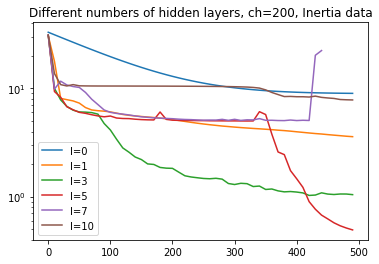

In [12]:
test_num_layer(200, [0,1,3,5,7,10], inertia)

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

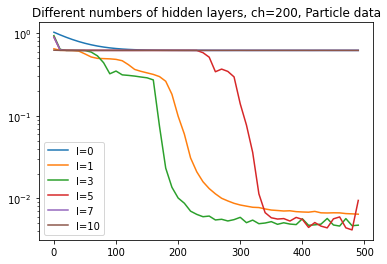

In [21]:
test_num_layer(200, [0,1,3,5,7,10], particle)

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Krylov Solving for Equivariant Subspace r<=10:   0%|          | 0/100 [00:00<?, ?it/s]

Krylov Solving for Equivariant Subspace r<=20:   0%|          | 0/100 [00:00<?, ?it/s]

Krylov Solving for Equivariant Subspace r<=40:   0%|          | 0/100 [00:00<?, ?it/s]

Krylov Solving for Equivariant Subspace r<=80:   0%|          | 0/100 [00:00<?, ?it/s]

Krylov Solving for Equivariant Subspace r<=160:   0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

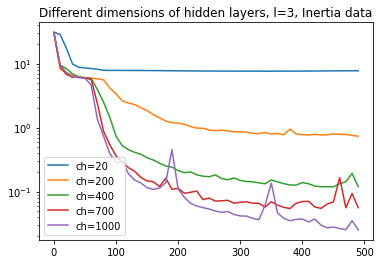

In [14]:
test_num_ch([20,200,400,700,1000], 3, inertia)

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Krylov Solving for Equivariant Subspace r<=10:   0%|          | 0/100 [00:00<?, ?it/s]

Krylov Solving for Equivariant Subspace r<=20:   0%|          | 0/100 [00:00<?, ?it/s]

Krylov Solving for Equivariant Subspace r<=40:   0%|          | 0/100 [00:00<?, ?it/s]

...

Krylov Solving for Equivariant Subspace r<=40:   0%|          | 0/100 [00:00<?, ?it/s]

Krylov Solving for Equivariant Subspace r<=10:   0%|          | 0/100 [00:00<?, ?it/s]

Krylov Solving for Equivariant Subspace r<=20:   0%|          | 0/100 [00:00<?, ?it/s]

Krylov Solving for Equivariant Subspace r<=40:   0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

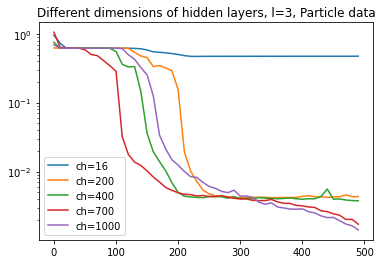

In [22]:
test_num_ch([16,200,400,700,1000], 3, particle)

## Different input representations
We test two cases for the input representation:
- the default input representation for the dataset
- only scalars for the input as a less constrained case


Number of weights for: 5V⁰+5V
Rep-In           Rep-Out            Unconstrained    Equivariant
---------------  ---------------  ---------------  -------------
5V⁰+5V           62V⁰+19V+6V²+V³             4000           1654
62V⁰+19V+6V²+V³  62V⁰+19V+6V²+V³            40000          22678
62V⁰+19V+6V²+V³  62V⁰+19V+6V²+V³            40000          22663
62V⁰+19V+6V²+V³  V²                          1800           1220


  0%|          | 0/500 [00:00<?, ?it/s]

Number of weights for: 20V⁰
Rep-In           Rep-Out            Unconstrained    Equivariant
---------------  ---------------  ---------------  -------------
20V⁰             62V⁰+19V+6V²+V³             4000           1831
62V⁰+19V+6V²+V³  62V⁰+19V+6V²+V³            40000          22681
62V⁰+19V+6V²+V³  62V⁰+19V+6V²+V³            40000          22639
62V⁰+19V+6V²+V³  V²                          1800           1221


  0%|          | 0/500 [00:00<?, ?it/s]

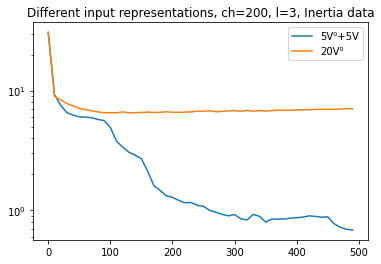

In [16]:
test_rep_in(200, 3, [5*Scalar+5*V,20*Scalar], inertia)

Number of weights for: 4V
Rep-In                    Rep-Out                     Unconstrained    Equivariant
------------------------  ------------------------  ---------------  -------------
4V                        68V⁰+9V+8V*+V*²+V²+2V⊗V*             3200            204
68V⁰+9V+8V*+V*²+V²+2V⊗V*  68V⁰+9V+8V*+V*²+V²+2V⊗V*            40000          10692
68V⁰+9V+8V*+V*²+V²+2V⊗V*  68V⁰+9V+8V*+V*²+V²+2V⊗V*            40000          10694
68V⁰+9V+8V*+V*²+V²+2V⊗V*  V⁰                                    200             80


  0%|          | 0/500 [00:00<?, ?it/s]

Number of weights for: 16V⁰
Rep-In                    Rep-Out                     Unconstrained    Equivariant
------------------------  ------------------------  ---------------  -------------
16V⁰                      68V⁰+9V+8V*+V*²+V²+2V⊗V*             3200           1280
68V⁰+9V+8V*+V*²+V²+2V⊗V*  68V⁰+9V+8V*+V*²+V²+2V⊗V*            40000          10670
68V⁰+9V+8V*+V*²+V²+2V⊗V*  68V⁰+9V+8V*+V*²+V²+2V⊗V*            40000          10701
68V⁰+9V+8V*+V*²+V²+2V⊗V*  V⁰                                    200             80


  0%|          | 0/500 [00:00<?, ?it/s]

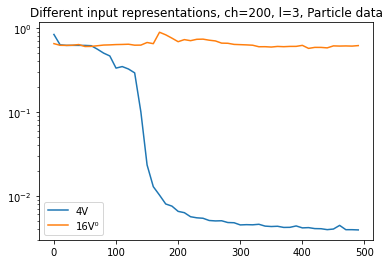

In [19]:
test_rep_in(200, 3, [4*V,16*Scalar], particle)

We then test different representation for the hidden layers. The input representation will be the default rep.
- the uniform representation given by uniform_rep()
- only scalar representations
- only vector representations
- only tensor representations

Number of weights for: 36V⁰+12V+3V²
Rep-In        Rep-Out         Unconstrained    Equivariant
------------  ------------  ---------------  -------------
5V⁰+5V        36V⁰+12V+3V²             1980            609
36V⁰+12V+3V²  36V⁰+12V+3V²             9801           4074
36V⁰+12V+3V²  36V⁰+12V+3V²             9801           4072
36V⁰+12V+3V²  V²                        891            555


  0%|          | 0/500 [00:00<?, ?it/s]

Number of weights for: 99V⁰
Rep-In    Rep-Out      Unconstrained    Equivariant
--------  ---------  ---------------  -------------
5V⁰+5V    99V⁰                  1980            495
99V⁰      99V⁰                  9801           9800
99V⁰      99V⁰                  9801           9800
99V⁰      V²                     891             99


  0%|          | 0/500 [00:00<?, ?it/s]

Number of weights for: 33V
Rep-In    Rep-Out      Unconstrained    Equivariant
--------  ---------  ---------------  -------------
5V⁰+5V    33V                   1980            165
33V       33V                   9801           1089
33V       33V                   9801           1089
33V       V²                     891            783


  0%|          | 0/500 [00:00<?, ?it/s]

Number of weights for: 11V²
Rep-In    Rep-Out      Unconstrained    Equivariant
--------  ---------  ---------------  -------------
5V⁰+5V    11V²                  1980           1361
11V²      11V²                  9801           9510
11V²      11V²                  9801           9501
11V²      V²                     891            866


  0%|          | 0/500 [00:00<?, ?it/s]

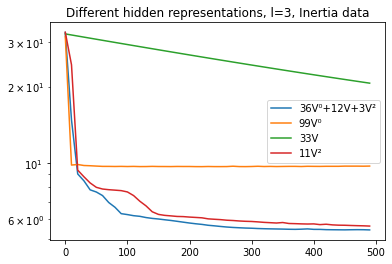

In [15]:
test_rep_hid([99,99*Scalar,33*V,11*V*V], 3, inertia)

Number of weights for: 32V⁰+4V+4V*+V*²+V⊗V*
Rep-In             Rep-Out              Unconstrained    Equivariant
-----------------  -----------------  ---------------  -------------
4V                 32V⁰+4V+4V*+2V⊗V*             1536             96
32V⁰+4V+4V*+2V⊗V*  32V⁰+4V+4V*+2V⊗V*             9216           2494
32V⁰+4V+4V*+2V⊗V*  32V⁰+4V+4V*+2V⊗V*             9216           2486
32V⁰+4V+4V*+2V⊗V*  V⁰                              96             38


  0%|          | 0/500 [00:00<?, ?it/s]

Number of weights for: 96V⁰
Rep-In    Rep-Out      Unconstrained    Equivariant
--------  ---------  ---------------  -------------
4V        96V⁰                  1536              0
96V⁰      96V⁰                  9216           9214
96V⁰      96V⁰                  9216           9214
96V⁰      V⁰                      96             96


  0%|          | 0/500 [00:00<?, ?it/s]

Number of weights for: 24V
Rep-In    Rep-Out      Unconstrained    Equivariant
--------  ---------  ---------------  -------------
4V        24V                   1536            288
24V       24V                   9216           1728
24V       24V                   9216           1728
24V       V⁰                      96              0


  0%|          | 0/500 [00:00<?, ?it/s]

Number of weights for: 6V²
Rep-In    Rep-Out      Unconstrained    Equivariant
--------  ---------  ---------------  -------------
4V        6V²                   1536              0
6V²       6V²                   9216           8042
6V²       6V²                   9216           8039
6V²       V⁰                      96             18


  0%|          | 0/500 [00:00<?, ?it/s]

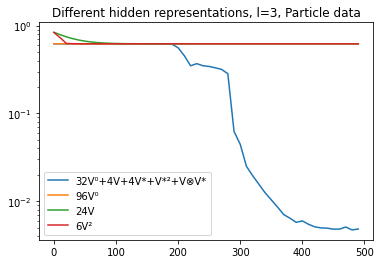

In [20]:
test_rep_hid([96,96*Scalar,24*V,6*V*V], 3, particle)

## Different Nonlinearities
For the representations of a layer an addition scalar gate is created. An activation function is then applied to the scalar gate.
There are two cases:
- scalar gates only for the non-scalar representations
- scalar gates for all representations

Activation functions used:
- sigmoid
- ReLU

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

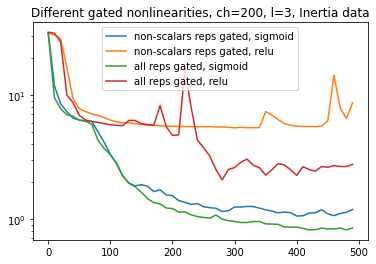

In [23]:
test_nonlin(200, 3, inertia)

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

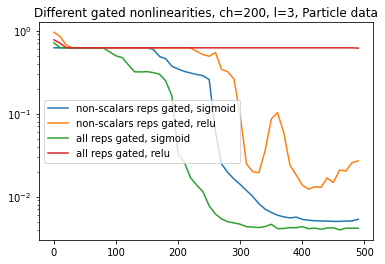

In [24]:
test_nonlin(200, 3 ,particle)

## Products of Groups
We test the EMLP network for products of groups.
- Inertia dataset: SU(5) x SO(3)
- Particle dataset: SU(4) x SO(1,3)

*The computation of the equivariant basis for group products seems to be buggy.*